# Cars Dataset Analysis

A reproducible exploratory analysis and small baseline price-regression experiment using an educational automotive dataset.

## 1. Project Goal

This notebook has two goals:

1. Inspect the structure, quality, and main descriptive patterns in the automotive data.
2. Build a transparent Linear Regression baseline for estimating `Price` from the available vehicle attributes.

The repository includes a small educational automotive dataset originally used for coursework. The original external dataset URL was not preserved in the archive.

The archived project reports documented `Price` in INR (Indian rupees). The model is an educational baseline, not a production valuation system.

## 2. Imports and Configuration

The random seed is fixed at 42. Repository paths are resolved from either the repository root or the `notebooks/` directory so the notebook can run from both locations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


def find_repository_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data" / "cars.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/cars.csv. Run the notebook from the repository "
        "root or the notebooks directory."
    )


REPOSITORY_ROOT = find_repository_root()
DATA_PATH = REPOSITORY_ROOT / "data" / "cars.csv"
FIGURES_DIRECTORY = REPOSITORY_ROOT / "docs" / "figures"
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

## 3. Dataset Loading

The raw CSV remains unchanged. Analysis transformations are applied only to in-memory copies.

In [2]:
raw_data = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {raw_data.shape[0]} rows x {raw_data.shape[1]} columns")
raw_data.head()

Dataset shape: 100 rows x 13 columns


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


## 4. Data Quality Checks

The checks below cover missing values, exact duplicates, repeated records after excluding the identifier, candidate identifiers, constant columns, categorical levels, and basic domain validity. IQR flags are diagnostic only; rows are not automatically removed as outliers.

In [3]:
column_profile = pd.DataFrame(
    {
        "dtype": raw_data.dtypes.astype(str),
        "missing": raw_data.isna().sum(),
        "missing_pct": raw_data.isna().mean().mul(100),
        "unique": raw_data.nunique(dropna=False),
    }
)
column_profile

,dtype,missing,missing_pct,unique
Car_ID,int64,0,0.00,100
Brand,str,0,0.00,11
Model,str,0,0.00,58
Year,int64,0,0.00,6
Kilometers_Driven,int64,0,0.00,18
Fuel_Type,str,0,0.00,2
Transmission,str,0,0.00,2
Owner_Type,str,0,0.00,3
Mileage,int64,0,0.00,15
Engine,int64,0,0.00,36


In [4]:
identifier_candidates = [
    column
    for column in raw_data.columns
    if raw_data[column].nunique(dropna=False) == len(raw_data)
    and ("id" in column.casefold() or column.casefold().endswith("_key"))
]
constant_columns = [
    column
    for column in raw_data.columns
    if raw_data[column].nunique(dropna=False) <= 1
]

record_columns = [column for column in raw_data.columns if column != "Car_ID"]
exact_duplicate_count = int(raw_data.duplicated().sum())
repeated_record_count = int(
    raw_data.duplicated(subset=record_columns).sum()
)
affected_repeated_records = int(
    raw_data.duplicated(subset=record_columns, keep=False).sum()
)

quality_summary = pd.Series(
    {
        "Exact duplicate rows": exact_duplicate_count,
        "Repeated records excluding Car_ID": repeated_record_count,
        "Rows involved in repeated records": affected_repeated_records,
        "Missing values": int(raw_data.isna().sum().sum()),
        "Candidate identifier columns": ", ".join(identifier_candidates) or "None",
        "Constant columns": ", ".join(constant_columns) or "None",
    },
    name="Result",
)
quality_summary.to_frame()

,Result
Exact duplicate rows,0
Repeated records excluding Car_ID,39
Rows involved in repeated records,77
Missing values,0
Candidate identifier columns,Car_ID
Constant columns,None


In [5]:
categorical_columns = raw_data.select_dtypes(exclude="number").columns.tolist()
categorical_summary = pd.DataFrame(
    [
        {
            "column": column,
            "unique_values": raw_data[column].nunique(dropna=False),
            "top_levels": ", ".join(
                f"{level} ({count})"
                for level, count in raw_data[column]
                .value_counts(dropna=False)
                .head(5)
                .items()
            ),
            "blank_or_whitespace": int(
                raw_data[column].astype(str).str.strip().eq("").sum()
            ),
        }
        for column in categorical_columns
    ]
)
categorical_summary

,column,unique_values,top_levels,blank_or_whitespace
0,Brand,11,"Ford (11), Hyundai (11), Tata (11), Toyota (10...",0
1,Model,58,"Mustang (3), C-Class (3), Verna (3), Altroz (3...",0
2,Fuel_Type,2,"Petrol (52), Diesel (48)",0
3,Transmission,2,"Automatic (57), Manual (43)",0
4,Owner_Type,3,"First (44), Second (43), Third (13)",0


In [6]:
validity_checks = pd.Series(
    {
        "Year outside 1886-2026": int(
            (~raw_data["Year"].between(1886, 2026)).sum()
        ),
        "Negative kilometers": int((raw_data["Kilometers_Driven"] < 0).sum()),
        "Non-positive mileage": int((raw_data["Mileage"] <= 0).sum()),
        "Non-positive engine capacity": int((raw_data["Engine"] <= 0).sum()),
        "Non-positive power": int((raw_data["Power"] <= 0).sum()),
        "Seats outside 2-9": int((~raw_data["Seats"].between(2, 9)).sum()),
        "Non-positive price": int((raw_data["Price"] <= 0).sum()),
    },
    name="Invalid rows",
)
validity_checks.to_frame()

,Invalid rows
Year outside 1886-2026,0
Negative kilometers,0
Non-positive mileage,0
Non-positive engine capacity,0
Non-positive power,0
Seats outside 2-9,0
Non-positive price,0


In [7]:
numeric_measure_columns = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Price",
]

iqr_diagnostics = []
for column in numeric_measure_columns:
    first_quartile = raw_data[column].quantile(0.25)
    third_quartile = raw_data[column].quantile(0.75)
    iqr = third_quartile - first_quartile

    if iqr == 0:
        flagged_count = pd.NA
        note = "IQR is zero; automatic filtering is not appropriate."
    else:
        lower_bound = first_quartile - 1.5 * iqr
        upper_bound = third_quartile + 1.5 * iqr
        flagged_count = int(
            (
                (raw_data[column] < lower_bound)
                | (raw_data[column] > upper_bound)
            ).sum()
        )
        note = "Diagnostic flag only; no rows removed."

    iqr_diagnostics.append(
        {
            "column": column,
            "Q1": first_quartile,
            "Q3": third_quartile,
            "IQR": iqr,
            "flagged_rows": flagged_count,
            "action": note,
        }
    )

pd.DataFrame(iqr_diagnostics)

,column,Q1,Q3,IQR,flagged_rows,action
0,Year,"2,017.75","2,019.00",1.25,2,Diagnostic flag only; no rows removed.
1,Kilometers_Driven,"22,000.00","32,000.00","10,000.00",3,Diagnostic flag only; no rows removed.
2,Mileage,15.00,19.00,4.00,0,Diagnostic flag only; no rows removed.
3,Engine,"1,462.00","2,143.00",681.00,1,Diagnostic flag only; no rows removed.
4,Power,103.00,187.00,84.00,7,Diagnostic flag only; no rows removed.
5,Seats,5.00,5.00,0.00,<NA>,IQR is zero; automatic filtering is not approp...
6,Price,"700,000.00","2,500,000.00","1,800,000.00",0,Diagnostic flag only; no rows removed.


`Car_ID` is a unique record identifier and is excluded from modeling. `Seats` is not constant, but its first and third quartiles are both 5, so its IQR is zero. This is why the notebook does not use blind sequential IQR filtering.

The raw dataset has unique IDs and no fully identical rows. However, multiple IDs share identical values across every remaining column. Those records remain visible in the raw EDA, but a conservative modeling copy removes repeated feature-target profiles before the train/test split to reduce duplicate leakage.

## 5. Exploratory Data Analysis

The EDA uses all 100 raw rows and focuses on price distribution, numeric relationships, and compact category summaries.

In [8]:
price_summary = raw_data["Price"].describe(
    percentiles=[0.25, 0.5, 0.75]
).to_frame("Price (INR)")
price_summary

,Price (INR)
count,100.00
mean,"1,574,000.00"
std,"1,000,264.61"
min,"450,000.00"
25%,"700,000.00"
50%,"1,300,000.00"
75%,"2,500,000.00"
max,"4,000,000.00"


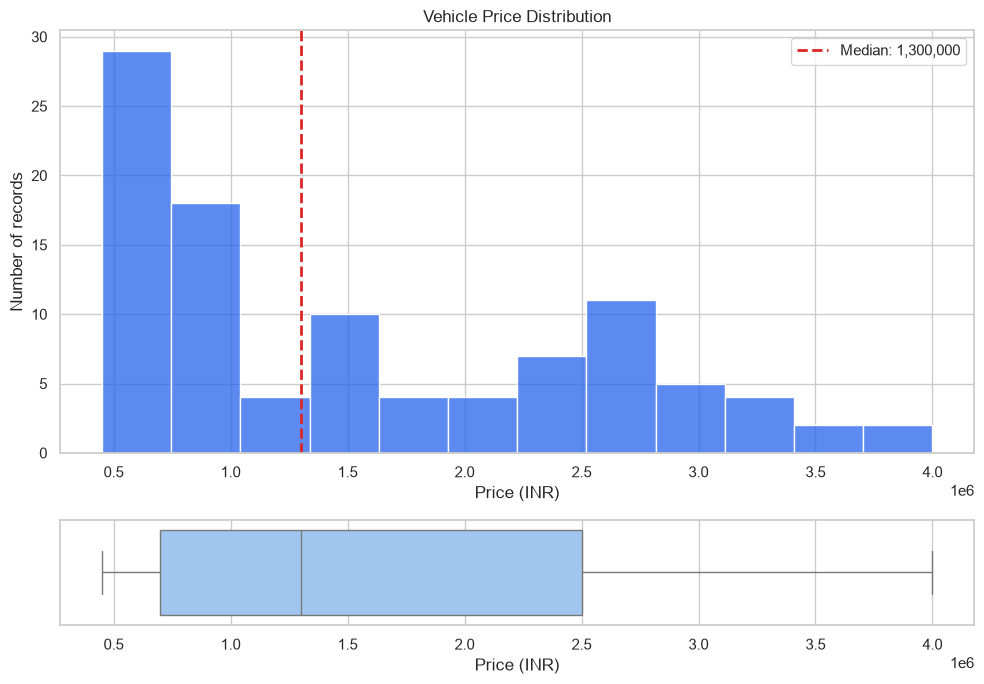

Saved: docs/figures/price-distribution.png


In [9]:
figure, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    gridspec_kw={"height_ratios": [4, 1]},
)

sns.histplot(
    data=raw_data,
    x="Price",
    bins=12,
    color="#2563eb",
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(
    raw_data["Price"].median(),
    color="#dc2626",
    linestyle="--",
    linewidth=2,
    label=f"Median: {raw_data['Price'].median():,.0f}",
)
axes[0].set_title("Vehicle Price Distribution")
axes[0].set_xlabel("Price (INR)")
axes[0].set_ylabel("Number of records")
axes[0].legend()

sns.boxplot(
    data=raw_data,
    x="Price",
    color="#93c5fd",
    ax=axes[1],
)
axes[1].set_xlabel("Price (INR)")

figure.tight_layout()
figure.savefig(
    FIGURES_DIRECTORY / "price-distribution.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
print("Saved: docs/figures/price-distribution.png")

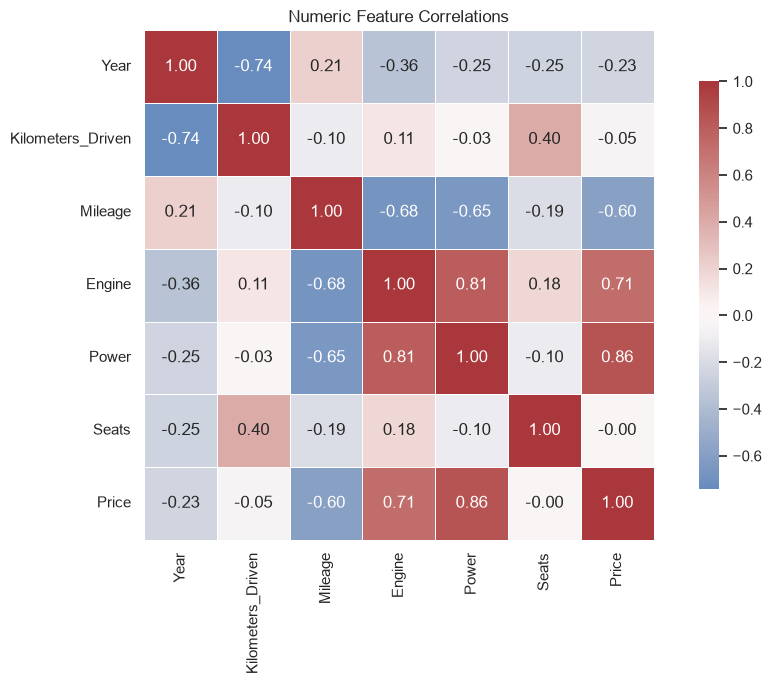

Saved: docs/figures/correlation-heatmap.png


In [10]:
numeric_analysis_columns = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Price",
]
numeric_correlation = raw_data[numeric_analysis_columns].corr()

figure, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(
    numeric_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axis,
)
axis.set_title("Numeric Feature Correlations")
figure.tight_layout()
figure.savefig(
    FIGURES_DIRECTORY / "correlation-heatmap.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
print("Saved: docs/figures/correlation-heatmap.png")

In [11]:
brand_price_summary = (
    raw_data.groupby("Brand", as_index=False)
    .agg(
        records=("Price", "size"),
        median_price=("Price", "median"),
        mean_price=("Price", "mean"),
    )
    .sort_values("mean_price", ascending=False)
    .reset_index(drop=True)
)
brand_price_summary

,Brand,records,median_price,mean_price
0,BMW,10,"2,900,000.00","3,030,000.00"
1,Mercedes,10,"2,700,000.00","2,880,000.00"
2,Audi,10,"2,600,000.00","2,570,000.00"
3,Toyota,10,"1,400,000.00","1,490,000.00"
4,Ford,11,"1,500,000.00","1,468,181.82"
5,Volkswagen,10,"1,125,000.00","1,115,000.00"
6,Mahindra,5,"900,000.00","940,000.00"
7,Honda,6,"800,000.00","808,333.33"
8,Tata,11,"600,000.00","795,454.55"
9,Hyundai,11,"800,000.00","713,636.36"


The raw sample is right-skewed: the mean price is above the median. `Power` and `Engine` have the strongest positive linear relationships with `Price`, while `Mileage` has a moderate negative relationship. These are descriptive associations in a small dataset and should not be interpreted as causal effects.

## 6. Data Preparation

Modeling uses one target (`Price`), six numeric features, and five categorical features. `Car_ID` is excluded. Repeated records that are identical across every non-ID column are removed before the split, leaving one copy of each feature-target profile.

In [12]:
model_data = (
    raw_data.drop_duplicates(subset=record_columns, keep="first")
    .reset_index(drop=True)
    .copy()
)

target_column = "Price"
numeric_features = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
]
categorical_features = [
    "Brand",
    "Model",
    "Fuel_Type",
    "Transmission",
    "Owner_Type",
]
feature_columns = numeric_features + categorical_features

features = model_data[feature_columns]
target = model_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

split_summary = pd.Series(
    {
        "Raw rows": len(raw_data),
        "Unique feature-target profiles": len(model_data),
        "Training rows": len(X_train),
        "Test rows": len(X_test),
        "Numeric features": len(numeric_features),
        "Categorical features": len(categorical_features),
    },
    name="Count",
)
split_summary.to_frame()

,Count
Raw rows,100
Unique feature-target profiles,61
Training rows,48
Test rows,13
Numeric features,6
Categorical features,5


In [13]:
numeric_pipeline = Pipeline(
    steps=[
        ("scale", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessing = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

baseline_model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("regression", LinearRegression()),
    ]
)
baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

## 7. Baseline Regression Model

The split occurs once with `random_state=42`. The preprocessing pipeline is fitted only when the model is fitted on the training data, so test rows do not influence scaling or category encoding.

In [14]:
baseline_model.fit(X_train, y_train)
predictions = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r_squared = r2_score(y_test, predictions)

metric_results = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R²"],
        "Value": [mae, rmse, r_squared],
    }
)
metric_results

,Metric,Value
0,MAE,"141,360.35"
1,RMSE,"234,404.24"
2,R²,0.90


In [15]:
prediction_results = (
    pd.DataFrame(
        {
            "Actual": y_test,
            "Predicted": predictions,
            "Absolute error": np.abs(y_test - predictions),
        }
    )
    .sort_values("Actual")
    .reset_index(drop=True)
)
prediction_results.round(2)

,Actual,Predicted,Absolute error
0,700000,"714,220.15","14,220.15"
1,750000,"742,853.57","7,146.43"
2,750000,"705,333.31","44,666.69"
3,750000,"676,527.73","73,472.27"
4,800000,"1,044,769.79","244,769.79"
5,800000,"569,132.79","230,867.21"
6,850000,"854,184.48","4,184.48"
7,1500000,"1,450,909.85","49,090.15"
8,1600000,"1,668,037.95","68,037.95"
9,1800000,"1,506,075.37","293,924.63"


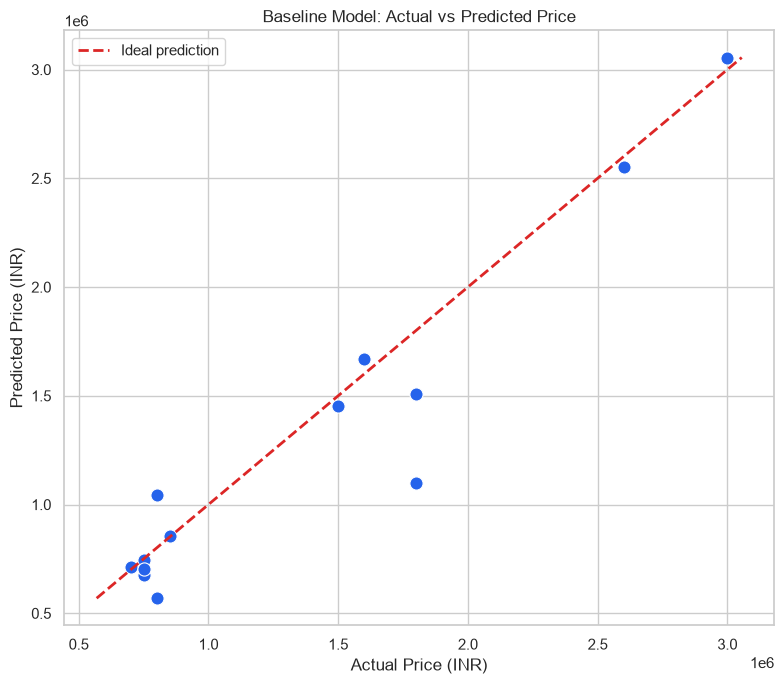

Saved: docs/figures/model-results.png


In [16]:
lower_limit = min(y_test.min(), predictions.min())
upper_limit = max(y_test.max(), predictions.max())

figure, axis = plt.subplots(figsize=(8, 7))
sns.scatterplot(
    x=y_test,
    y=predictions,
    s=90,
    color="#2563eb",
    edgecolor="white",
    linewidth=0.8,
    ax=axis,
)
axis.plot(
    [lower_limit, upper_limit],
    [lower_limit, upper_limit],
    color="#dc2626",
    linestyle="--",
    linewidth=2,
    label="Ideal prediction",
)
axis.set_title("Baseline Model: Actual vs Predicted Price")
axis.set_xlabel("Actual Price (INR)")
axis.set_ylabel("Predicted Price (INR)")
axis.legend()

figure.tight_layout()
figure.savefig(
    FIGURES_DIRECTORY / "model-results.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
print("Saved: docs/figures/model-results.png")

## 8. Model Interpretation

The coefficients below describe how the fitted baseline combines standardized numeric inputs and one-hot encoded categories. They are not causal effects. Because the dataset is small and `Model` has high cardinality, coefficient magnitudes can be unstable and should be read only as diagnostics.

In [17]:
transformed_feature_names = baseline_model.named_steps[
    "preprocessing"
].get_feature_names_out()
coefficients = baseline_model.named_steps["regression"].coef_

coefficient_summary = (
    pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "coefficient": coefficients,
            "absolute_coefficient": np.abs(coefficients),
        }
    )
    .sort_values("absolute_coefficient", ascending=False)
    .head(12)
    .drop(columns="absolute_coefficient")
    .reset_index(drop=True)
)
coefficient_summary

,feature,coefficient
0,Brand_BMW,"583,888.97"
1,Power,"573,811.85"
2,Model_A6,"567,808.75"
3,Model_Fortuner,"506,978.47"
4,Model_GLE,"504,718.46"
5,Brand_Audi,"468,438.35"
6,Brand_Mercedes,"438,670.89"
7,Model_Mustang,"-426,713.96"
8,Brand_Mahindra,"-424,479.68"
9,Model_Sonata,"-405,808.73"


## 9. Key Findings

The summary below is generated from the executed analysis so the reported metrics stay aligned with the notebook outputs.

In [18]:
strongest_positive_feature = (
    numeric_correlation["Price"]
    .drop("Price")
    .sort_values(ascending=False)
    .index[0]
)
strongest_positive_correlation = numeric_correlation.loc[
    strongest_positive_feature, "Price"
]
highest_mean_price_brand = brand_price_summary.iloc[0]

display(
    Markdown(
        f'''
        - The raw dataset contains **{len(raw_data)} rows and {raw_data.shape[1]} columns**, with no missing values or exact duplicate rows.
        - Excluding the unique `Car_ID`, **{repeated_record_count} repeated feature-target records** were identified. The baseline therefore uses **{len(model_data)} unique profiles** before splitting.
        - Median price is **{raw_data['Price'].median():,.0f} INR**; the mean is **{raw_data['Price'].mean():,.0f} INR**, showing a right-skewed sample.
        - **{strongest_positive_feature}** has the strongest positive numeric correlation with price (**r = {strongest_positive_correlation:.2f}**).
        - **{highest_mean_price_brand['Brand']}** has the highest mean price in this sample (**{highest_mean_price_brand['mean_price']:,.0f} INR across {int(highest_mean_price_brand['records'])} records**).
        - On the held-out test set, the Linear Regression baseline records **MAE {mae:,.0f} INR**, **RMSE {rmse:,.0f} INR**, and **R² {r_squared:.3f}**.
        '''
    )
)


        - The raw dataset contains **100 rows and 13 columns**, with no missing values or exact duplicate rows.
        - Excluding the unique `Car_ID`, **39 repeated feature-target records** were identified. The baseline therefore uses **61 unique profiles** before splitting.
        - Median price is **1,300,000 INR**; the mean is **1,574,000 INR**, showing a right-skewed sample.
        - **Power** has the strongest positive numeric correlation with price (**r = 0.86**).
        - **BMW** has the highest mean price in this sample (**3,030,000 INR across 10 records**).
        - On the held-out test set, the Linear Regression baseline records **MAE 141,360 INR**, **RMSE 234,404 INR**, and **R² 0.900**.
        

## 10. Limitations

- The dataset is small: 100 raw rows and fewer unique feature-target profiles after conservative deduplication.
- The original external dataset URL was not preserved, so source lineage and collection methodology cannot be independently verified from this archive.
- Several categorical values, especially `Model`, are high-cardinality relative to the sample size. Unseen test categories are safely ignored by the encoder, but generalization remains uncertain.
- A single train/test split provides only one performance snapshot. Results can change materially with another sample.
- Correlations and regression coefficients are associations, not causal effects.
- The Linear Regression result is an educational baseline. It is not a deployed model, production prediction engine, or substitute for a real vehicle valuation process.